In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/sales_data.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Handle missing values
df['industry'] = df['industry'].fillna('Unknown')
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].mean())

In [3]:
# Create a year-month column for time-based analysis
df['year_month'] = df['date'].dt.to_period('M')

# Group sales data by month
grouped_data = df.groupby('year_month')

# Calculate total monthly revenue
monthly_revenue = grouped_data['revenue'].sum()

# Convert the result into a DataFrame
monthly_sales = monthly_revenue.reset_index()

# Display the first few rows
monthly_sales.head()

,year_month,revenue
0,2022-01,21702882
1,2022-02,22343087
2,2022-03,25141816
3,2022-04,17646783
4,2022-05,17751973


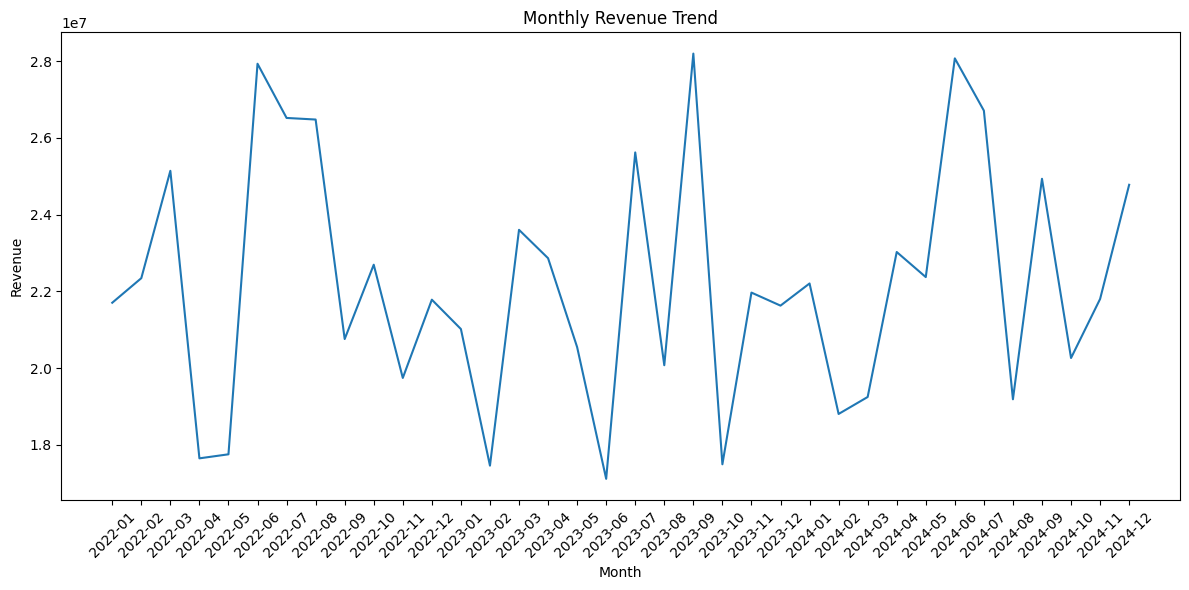

In [4]:
# Create a line chart for monthly revenue

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['year_month'].astype(str),
    monthly_sales['revenue']
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [5]:
# Calculate revenue by state
state_revenue = (
    df.groupby('state')['revenue']
      .sum()
      .reset_index()
)

state_revenue

,state,revenue
0,NSW,136191339
1,NT,120691847
2,QLD,132293997
3,SA,142877368
4,VIC,129430994
5,WA,137979515


In [6]:
# Calculate total revenue by state
state_revenue = (
    df.groupby('state')['revenue']
      .sum()
      .reset_index()
)

# Sort states by revenue in descending order
state_revenue = state_revenue.sort_values(
    by='revenue',
    ascending=False
)

state_revenue

,state,revenue
3,SA,142877368
5,WA,137979515
0,NSW,136191339
2,QLD,132293997
4,VIC,129430994
1,NT,120691847


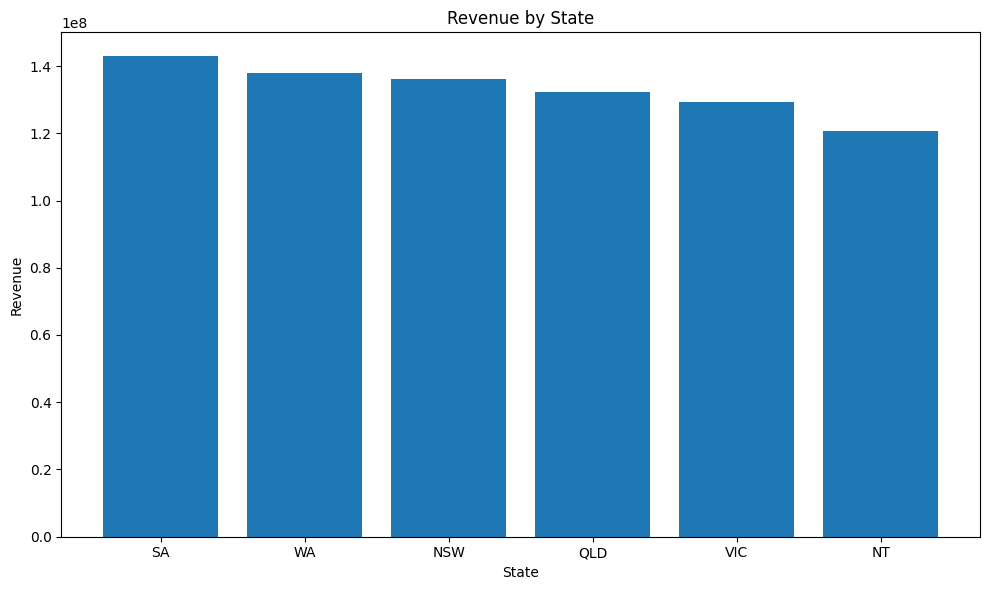

In [7]:
# Create a bar chart for revenue by state

plt.figure(figsize=(10,6))

plt.bar(
    state_revenue['state'],
    state_revenue['revenue']
)

plt.title('Revenue by State')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.tight_layout()

plt.show()

In [8]:
state_vehicle_revenue = (
    df.groupby(['state', 'vehicle_type'])['revenue']
        .sum()
        .reset_index()

)

state_vehicle_revenue  = state_vehicle_revenue.sort_values(
    by='revenue',
    ascending=False
)

In [9]:
state_vehicle_revenue.head(15)

,state,vehicle_type,revenue
6,NT,Construction Equipment,36963590
27,WA,Heavy Duty Truck,34825861
16,SA,Construction Equipment,33985936
17,SA,Heavy Duty Truck,33943665
28,WA,Light Commercial,33509882
3,NSW,Light Commercial,30900984
20,VIC,Bus,30460272
25,WA,Bus,29979098
12,QLD,Heavy Duty Truck,29347691
0,NSW,Bus,29213339


In [10]:
# Create a pivot table for heatmap visualization

state_vehicle_pivot = state_vehicle_revenue.pivot(
    index='state',
    columns='vehicle_type',
    values='revenue'
)

state_vehicle_pivot

vehicle_type,Bus,Construction Equipment,Heavy Duty Truck,Light Commercial,Medium Duty Truck
state,,,,,
NSW,29213339,27893682,23810421,30900984,24372913
NT,13125764,36963590,25171802,22999436,22431255
QLD,26773447,27240133,29347691,21507042,27425684
SA,21778177,33985936,33943665,25598024,27571566
VIC,30460272,23375134,26868374,20840908,27886306
WA,29979098,16777051,34825861,33509882,22887623


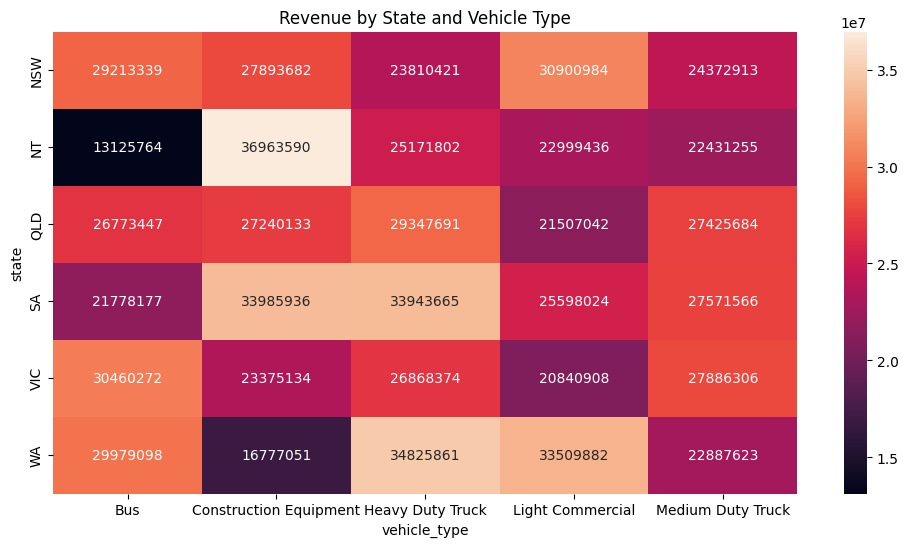

In [11]:
plt.figure(figsize=(12,6))

sns.heatmap(
    state_vehicle_pivot,
    annot=True,
    fmt='.0f'
)

plt.title('Revenue by State and Vehicle Type')

plt.show()

In [12]:
state_vehicle_units = (
    df.groupby(['state', 'vehicle_type'])['units_sold']
      .sum()
      .reset_index()
)

In [14]:
#create state-vehicle pivot for units sold

state_vehicle_units_pivot = state_vehicle_units.pivot(
    index='state',
    columns='vehicle_type',
    values='units_sold'
)          
state_vehicle_units_pivot

vehicle_type,Bus,Construction Equipment,Heavy Duty Truck,Light Commercial,Medium Duty Truck
state,,,,,
NSW,93,114,82,99,88
NT,47,129,84,82,86
QLD,95,81,97,69,95
SA,82,101,111,91,83
VIC,98,83,102,65,84
WA,100,48,115,107,77


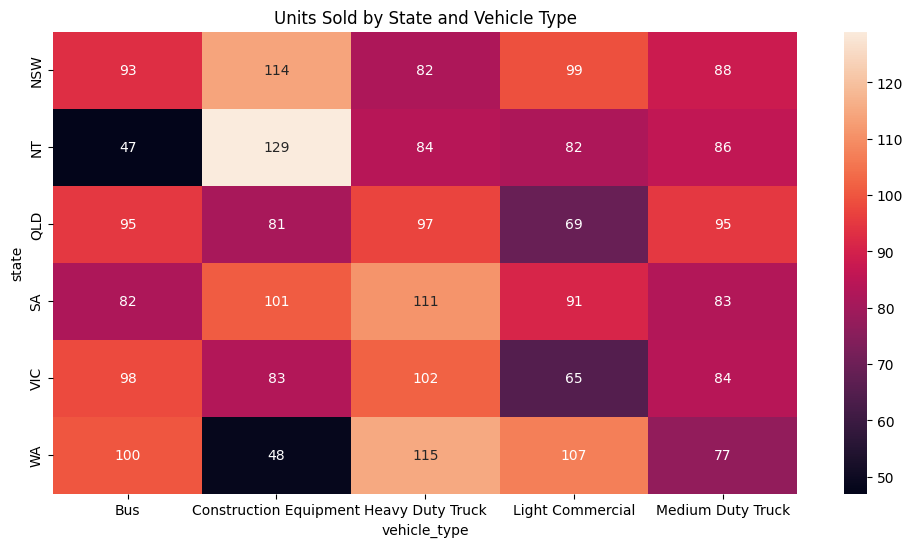

In [15]:
plt.figure(figsize=(12,6))              
sns.heatmap(
    state_vehicle_units_pivot,
    annot=True,
    fmt='.0f'
)                                       
plt.title('Units Sold by State and Vehicle Type')
plt.show()  

In [21]:
#industry revenue
industry_revenue = (
    df.groupby('industry')['revenue']
      .sum()
      .reset_index()
      .sort_values(by='revenue', ascending=False)
)

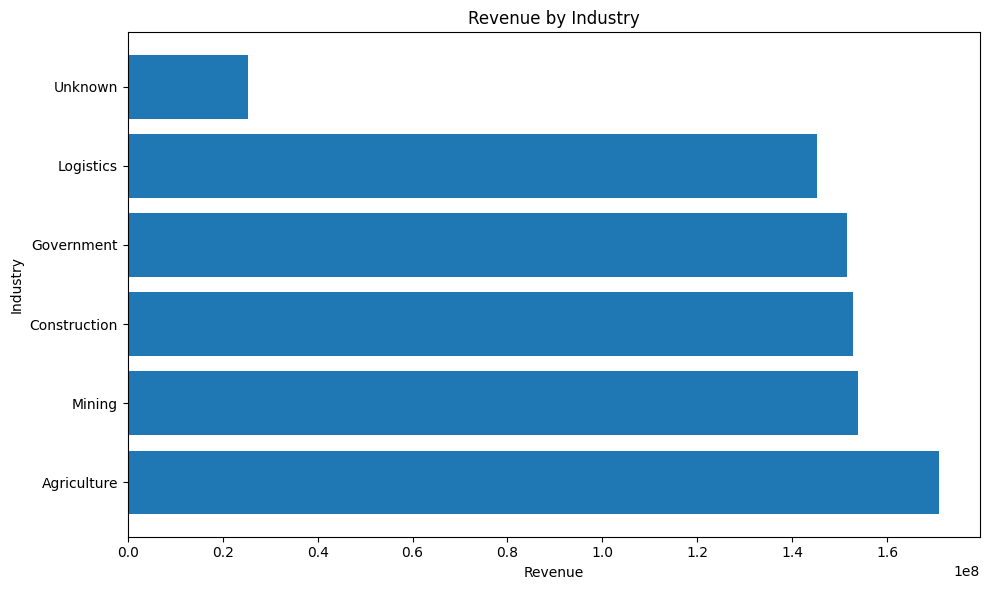

In [22]:
# Revenue by industry

plt.figure(figsize=(10,6))

plt.barh(
    industry_revenue['industry'],
    industry_revenue['revenue']
)

plt.title('Revenue by Industry')
plt.xlabel('Revenue')
plt.ylabel('Industry')

plt.tight_layout()

plt.show()

In [23]:
#vehicle type revenue
vehicle_revenue = (
    df.groupby('vehicle_type')['revenue']
      .sum()
      .reset_index()
      .sort_values(by='revenue', ascending=False)
)   

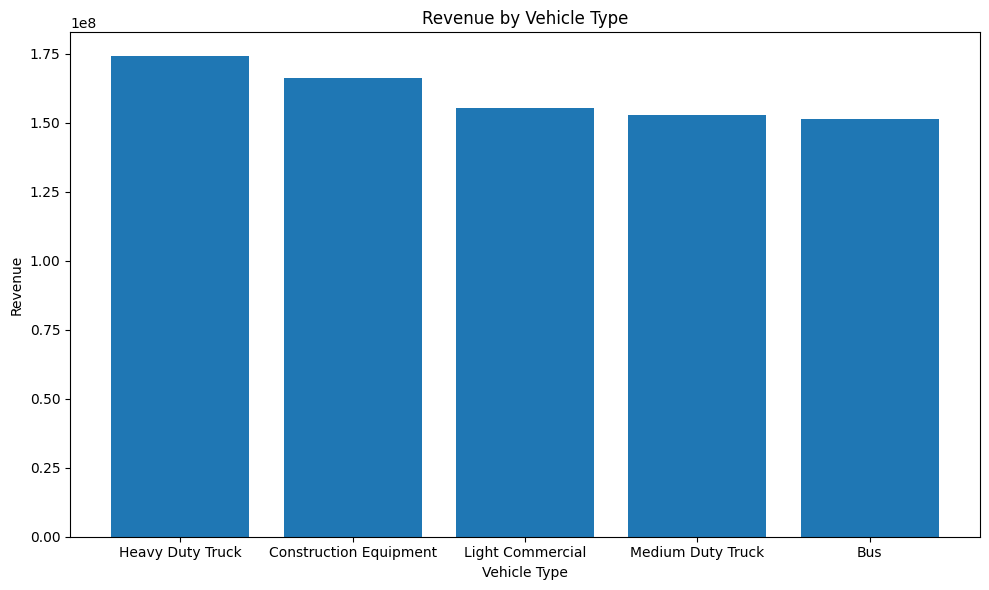

In [24]:
#revenue by vehicle type
plt.figure(figsize=(10,6))  
plt.bar(
    vehicle_revenue['vehicle_type'],
    vehicle_revenue['revenue']
)
plt.title('Revenue by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue')
plt.tight_layout()          
plt.show()

